<a href="https://colab.research.google.com/github/shifa441/Neural_Network_assignment/blob/main/problem_set_01_id_223017812(cnn_xray).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [6]:
train_dir = "/content/drive/MyDrive/Archive/train"
val_dir = "/content/drive/MyDrive/Archive/val"
test_dir = "/content/drive/MyDrive/Archive/test"

print("Train path exists:", os.path.exists(train_dir))
print("Validation path exists:", os.path.exists(val_dir))
print("Test path exists:", os.path.exists(test_dir))

Train path exists: True
Validation path exists: True
Test path exists: True


In [10]:
print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))
print("Test folders:", os.listdir(test_dir))

Train folders: ['PNEUMONIA', 'NORMAL']
Validation folders: ['PNEUMONIA', 'NORMAL']
Test folders: ['PNEUMONIA', 'NORMAL']


In [11]:
img_height = 128
img_width = 128
batch_size = 16

In [12]:
train_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
val_datagen = ImageDataGenerator(rescale=1.0 / 255.0)
test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [13]:
print("Class indices:", train_generator.class_indices)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


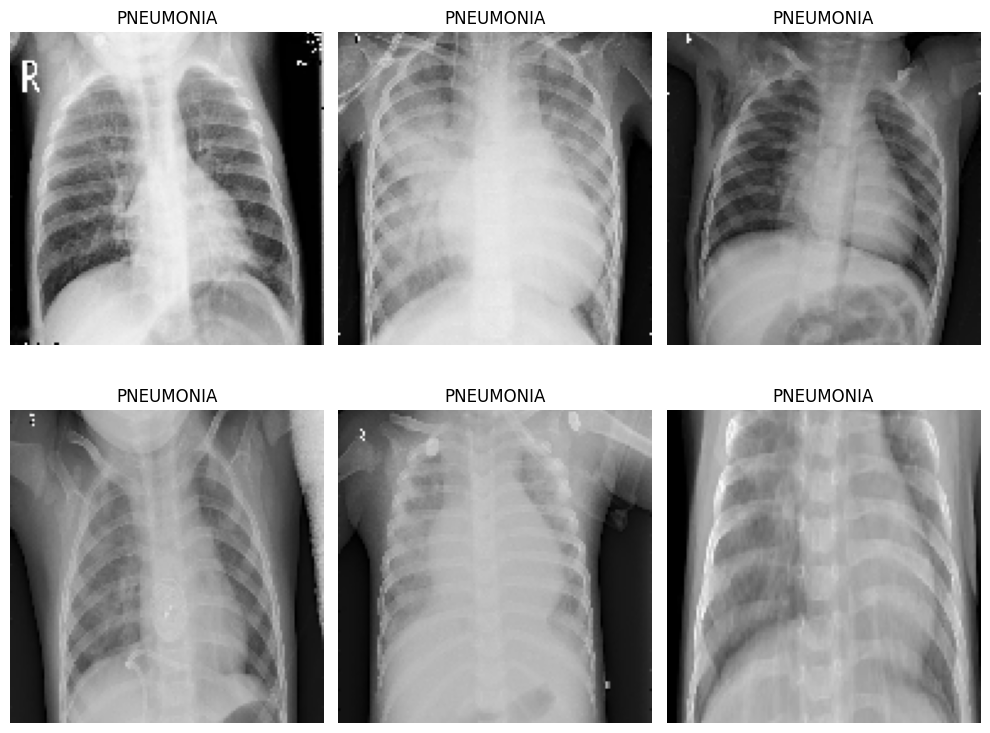

In [14]:
images, labels = next(train_generator)

plt.figure(figsize=(10, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title("PNEUMONIA" if labels[i] == 1 else "NORMAL")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
from tensorflow.keras import Input

model = Sequential([
    Input(shape=(img_height, img_width, 3)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

In [18]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 826,529 (3.15 MB)

 Trainable params: 826,529 (3.15 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [32]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=[early_stop]
)

Epoch 1/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 143s 438ms/step - accuracy: 0.9868 - loss: 0.0363 - val_accuracy: 0.8750 - val_loss: 0.1992
Epoch 2/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 143s 440ms/step - accuracy: 0.9885 - loss: 0.0300 - val_accuracy: 0.9375 - val_loss: 0.2553
Epoch 3/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 200s 433ms/step - accuracy: 0.9881 - loss: 0.0334 - val_accuracy: 0.7500 - val_loss: 0.8667
Epoch 4/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 147s 451ms/step - accuracy: 0.9873 - loss: 0.0321 - val_accuracy: 0.9375 - val_loss: 0.1247
Epoch 5/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 143s 437ms/step - accuracy: 0.9908 - loss: 0.0267 - val_accuracy: 1.0000 - val_loss: 0.0414
Epoch 6/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 140s 429ms/step - accuracy: 0.9910 - loss: 0.0247 - val_accuracy: 0.9375 - val_loss: 0.1305
Epoch 7/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 142s 435ms/step - accuracy: 0.9906 - loss: 0.0243 - val_accuracy: 0.8750 - val_loss: 0.3311
Epoch 8/8
326/326 ━━━━━━━━━━━━━━━━━━━━ 141s 433ms/step - accuracy: 0.9918 - loss: 0

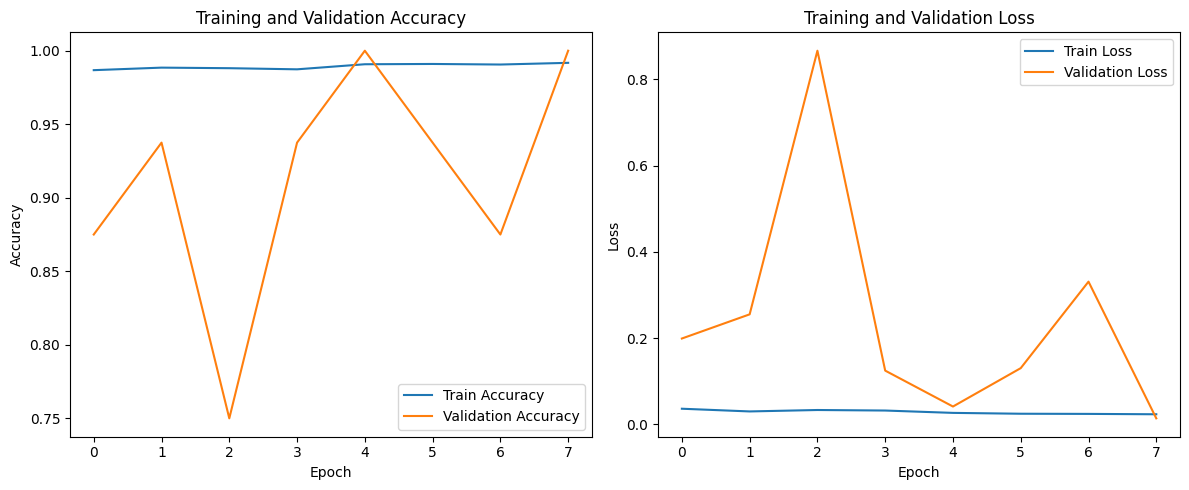

In [33]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [34]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - accuracy: 0.7708 - loss: 2.5120
Test Loss: 2.512
Test Accuracy: 0.7708


In [35]:
predicted_probablities = model.predict(test_generator)
y_pred = (predicted_probablities > 0.5).astype(int).flatten()
y_true = test_generator.classes

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step
Confusion Matrix:
[[ 93 141]
 [  2 388]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.98      0.40      0.57       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.86      0.70      0.70       624
weighted avg       0.83      0.77      0.74       624

